# YouTube Comments Scraper & Dataset Generator

## 1. Dependencies & Imports

In [65]:
!pip install youtube-comment-downloader pandas nltk gensim scikit-learn vaderSentiment transformers torch spacy wordcloud matplotlib seaborn --quiet
!python -m spacy download en_core_web_sm --quiet

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [89]:
import re
import unicodedata
from itertools import islice
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import spacy
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim.models import Word2Vec
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline
from wordcloud import WordCloud
from youtube_comment_downloader import YoutubeCommentDownloader, SORT_BY_POPULAR

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

## 3. Configuration

In [90]:
VIDEO_URL = 'https://www.youtube.com/watch?v=O0cs8aIXgkc'
MAX_COMMENTS = 1000
OUTPUT_CSV = 'youtube_comments_dataset.csv'

## 4. Scrape Comments

In [91]:
downloader = YoutubeCommentDownloader()
comments_gen = downloader.get_comments_from_url(VIDEO_URL, sort_by=SORT_BY_POPULAR)

raw_comments = list(islice(comments_gen, MAX_COMMENTS))
print(f'Scraped {len(raw_comments)} comments.')

Scraped 1000 comments.


## 5. Build Dataset

In [92]:
records = [{'comment_id': c.get('cid', ''), 'text': c.get('text', '')} for c in raw_comments]
df = pd.DataFrame(records)

df

,comment_id,text
0,UgyIlzTVTDx0Vdh60QB4AaABAg,Imagine going on the highway and seeing an unr...
1,UgzwU5OMQSAHhzJL3o54AaABAg,Being iconic doesn't require it to be rare. Th...
2,UgwR1E8NtuO1pggeLtF4AaABAg,"Okay, that intro sequence with the spinning ca..."
3,UgyorHIgxnJOLUyr-754AaABAg,Here’s some food for thought: if the car gets ...
4,Ugw-lqBOrNH7aEMQcgV4AaABAg,"As a european, cars like this are just insane...."
...,...,...
995,UgyuJCi8bevIVhm4gBN4AaABAg.A1_zWZQB4xCA1bYTlwlsRK,​ @JohnFinch-e9j Exactly. If you want pratica...
996,UgyuJCi8bevIVhm4gBN4AaABAg.A1_zWZQB4xCA1a6z17c9yo,"To make up for uh, deficiencies, in other area..."
997,UgyuJCi8bevIVhm4gBN4AaABAg.A1_zWZQB4xCA1a7AWMaZW_,Same reason people buy Bugattis and not go 300...
998,UgyuJCi8bevIVhm4gBN4AaABAg.A1_zWZQB4xCA1a2h7O3LLD,I borrowed an F150 for like a wk and it's actu...


## 6. Export to CSV

In [93]:
df.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')
print(f'Saved {len(df)} rows to {OUTPUT_CSV}')

Saved 1000 rows to youtube_comments_dataset.csv


---

## Phase 2 — Data Cleaning & Preprocessing for Sentiment Analysis

**Steps:**
1. Reset IDs (1 → n)
2. Normalize text (lowercase, remove URLs / emojis / punctuation / numbers)
3. Remove duplicates & empty rows
4. Remove stop words (multilingual)
5. Tokenization
6. Vectorization — TF-IDF matrix + Word2Vec embeddings
7. Save cleaned dataset

In [94]:
df = pd.read_csv('youtube_comments_dataset.csv', encoding='utf-8-sig')
df.head()

,comment_id,text
0,UgyIlzTVTDx0Vdh60QB4AaABAg,Imagine going on the highway and seeing an unr...
1,UgzwU5OMQSAHhzJL3o54AaABAg,Being iconic doesn't require it to be rare. Th...
2,UgwR1E8NtuO1pggeLtF4AaABAg,"Okay, that intro sequence with the spinning ca..."
3,UgyorHIgxnJOLUyr-754AaABAg,Here’s some food for thought: if the car gets ...
4,Ugw-lqBOrNH7aEMQcgV4AaABAg,"As a european, cars like this are just insane...."


In [95]:
df = df.drop(columns=['comment_id'])
df.insert(0, 'comment_id', range(1, len(df) + 1))
df.head()

,comment_id,text
0,1,Imagine going on the highway and seeing an unr...
1,2,Being iconic doesn't require it to be rare. Th...
2,3,"Okay, that intro sequence with the spinning ca..."
3,4,Here’s some food for thought: if the car gets ...
4,5,"As a european, cars like this are just insane...."


In [96]:
STOP_WORDS = set()
for lang in ('english', 'french', 'portuguese', 'arabic'):
    try:
        STOP_WORDS.update(stopwords.words(lang))
    except OSError:
        pass

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[@#]\w+', '', text)
    text = re.sub(r'\b\d{1,2}:\d{2}(?::\d{2})?\b', '', text)
    text = unicodedata.normalize('NFKD', text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(clean_text)
df[['text', 'text_clean']].head(5)

,text,text_clean
0,Imagine going on the highway and seeing an unr...,imagine going on the highway and seeing an unr...
1,Being iconic doesn't require it to be rare. Th...,being iconic doesn t require it to be rare the...
2,"Okay, that intro sequence with the spinning ca...",okay that intro sequence with the spinning cam...
3,Here’s some food for thought: if the car gets ...,heres some food for thought if the car gets in...
4,"As a european, cars like this are just insane....",as a european cars like this are just insane t...


In [97]:
### 12. Remove Duplicates & Empty Rows
before = len(df)

df = df.drop_duplicates(subset='text_clean')
df = df[df['text_clean'].str.strip().astype(bool)]  # drop empty/whitespace-only

# Re-index comment_id after deduplication
df = df.reset_index(drop=True)
df['comment_id'] = range(1, len(df) + 1)

print(f'Removed {before - len(df)} rows (duplicates / empty). Remaining: {len(df)}')

Removed 35 rows (duplicates / empty). Remaining: 965


In [98]:
def tokenize_and_filter(text: str) -> list[str]:
    tokens = word_tokenize(text)
    return [t for t in tokens if t not in STOP_WORDS and len(t) > 1]

df['tokens'] = df['text_clean'].apply(tokenize_and_filter)
df['text_filtered'] = df['tokens'].apply(lambda toks: ' '.join(toks))
df[['text_clean', 'tokens']].head(5)

,text_clean,tokens
0,imagine going on the highway and seeing an unr...,"[imagine, going, highway, seeing, unrendered, ..."
1,being iconic doesn t require it to be rare the...,"[iconic, require, rare, vw, beetle, iconic, de..."
2,okay that intro sequence with the spinning cam...,"[okay, intro, sequence, spinning, camera, tran..."
3,heres some food for thought if the car gets in...,"[heres, food, thought, car, gets, accident, cr..."
4,as a european cars like this are just insane t...,"[european, cars, like, insane, thing, even, fi..."


In [99]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
tfidf_matrix = tfidf.fit_transform(df['text_filtered'])
print(f'TF-IDF matrix: {tfidf_matrix.shape}')

TF-IDF matrix: (965, 1838)


In [100]:
w2v_model = Word2Vec(
    sentences=df['tokens'].tolist(),
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=10,
    seed=42,
)

def mean_embedding(tokens: list[str], model: Word2Vec) -> np.ndarray:
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

df['w2v_embedding'] = df['tokens'].apply(lambda t: mean_embedding(t, w2v_model))
print(f'Word2Vec — vocab: {len(w2v_model.wv)}, dim: {w2v_model.vector_size}')

Word2Vec — vocab: 1351, dim: 100


In [101]:
cleaned_csv = 'youtube_comments_cleaned.csv'
df[['comment_id', 'text', 'text_clean', 'text_filtered', 'tokens']].to_csv(
    cleaned_csv, index=False, encoding='utf-8-sig'
)
print(f'Cleaned CSV → {cleaned_csv}  ({len(df)} rows)')

Cleaned CSV → youtube_comments_cleaned.csv  (965 rows)


---

## Phase 3 — Sentiment Analysis, Topic Modelling & NER

**Steps:**
1. VADER — rule-based sentiment (positive / negative / neutral)
2. DistilBERT — transformer-based sentiment (positive / negative)
3. VADER vs DistilBERT agreement
4. LDA — topic modelling (5 topics)
5. NER — named entity recognition (ORG, PRODUCT, PERSON, GPE)
6. Save final results

In [102]:
### 17. Load Cleaned Dataset
df = pd.read_csv('youtube_comments_cleaned.csv', encoding='utf-8-sig')
df['tokens'] = df['tokens'].apply(eval)   # restore list from string
print(f'Loaded {len(df)} rows')
df.head(3)

Loaded 965 rows


,comment_id,text,text_clean,text_filtered,tokens
0,1,Imagine going on the highway and seeing an unr...,imagine going on the highway and seeing an unr...,imagine going highway seeing unrendered car,"[imagine, going, highway, seeing, unrendered, ..."
1,2,Being iconic doesn't require it to be rare. Th...,being iconic doesn t require it to be rare the...,iconic require rare vw beetle iconic despite o...,"[iconic, require, rare, vw, beetle, iconic, de..."
2,3,"Okay, that intro sequence with the spinning ca...",okay that intro sequence with the spinning cam...,okay intro sequence spinning camera transition...,"[okay, intro, sequence, spinning, camera, tran..."


In [103]:
### 18. VADER Sentiment
# Uses text_clean — preserves word meaning without emojis/URLs
vader = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    score = vader.polarity_scores(str(text))['compound']
    label = 'positive' if score >= 0.05 else ('negative' if score <= -0.05 else 'neutral')
    return label, round(score, 4)

results = df['text_clean'].apply(vader_sentiment)
df['vader_label'] = results.apply(lambda x: x[0])
df['vader_score'] = results.apply(lambda x: x[1])

print('VADER distribution:')
print(df['vader_label'].value_counts().to_string())
df[['text_clean', 'vader_label', 'vader_score']].head(5)

VADER distribution:
vader_label
positive    429
neutral     318
negative    218


,text_clean,vader_label,vader_score
0,imagine going on the highway and seeing an unr...,neutral,0.0000
1,being iconic doesn t require it to be rare the...,neutral,0.0000
2,okay that intro sequence with the spinning cam...,positive,0.7184
3,heres some food for thought if the car gets in...,negative,-0.8890
4,as a european cars like this are just insane t...,negative,-0.1053


In [104]:
### 19. DistilBERT Sentiment
# Binary classifier (positive / negative) — downloads ~260 MB on first run
# Uses CPU by default; set device=0 for GPU
distilbert_pipe = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    truncation=True,
    max_length=512,
    device=-1,
)

texts = [t if str(t).strip() else 'empty' for t in df['text_clean'].fillna('')]
bert_out = distilbert_pipe(texts, batch_size=32)

df['distilbert_label'] = [r['label'].lower() for r in bert_out]
df['distilbert_score'] = [round(r['score'], 4) for r in bert_out]

print('DistilBERT distribution:')
print(df['distilbert_label'].value_counts().to_string())
df[['text_clean', 'distilbert_label', 'distilbert_score']].head(5)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 6839.36it/s]


DistilBERT distribution:
distilbert_label
negative    634
positive    331


,text_clean,distilbert_label,distilbert_score
0,imagine going on the highway and seeing an unr...,negative,0.9868
1,being iconic doesn t require it to be rare the...,positive,0.9974
2,okay that intro sequence with the spinning cam...,positive,0.9998
3,heres some food for thought if the car gets in...,negative,0.9993
4,as a european cars like this are just insane t...,negative,0.9998


In [105]:
### 20. VADER vs DistilBERT Agreement
# Compare only on rows where VADER is not neutral (DistilBERT has no neutral class)
mask = df['vader_label'] != 'neutral'
agreement = (df.loc[mask, 'vader_label'] == df.loc[mask, 'distilbert_label']).mean()
print(f'Agreement on non-neutral rows ({mask.sum()} / {len(df)}): {agreement:.1%}')

print('\nSide-by-side distribution:')
pd.DataFrame({
    'VADER': df['vader_label'].value_counts(),
    'DistilBERT': df['distilbert_label'].value_counts(),
}).fillna(0).astype(int)

Agreement on non-neutral rows (647 / 965): 59.7%

Side-by-side distribution:


,VADER,DistilBERT
negative,218,634
neutral,318,0
positive,429,331


In [106]:
### 21. LDA Topic Modelling
cv = CountVectorizer(max_features=3000, min_df=2)
dtm = cv.fit_transform(df['text_filtered'].fillna(''))

lda = LatentDirichletAllocation(n_components=5, random_state=42, max_iter=20)
lda.fit(dtm)

vocab = cv.get_feature_names_out()
print('Top 10 words per topic:\n')
for i, topic in enumerate(lda.components_):
    top_words = [vocab[j] for j in topic.argsort()[-10:][::-1]]
    print(f'  Topic {i+1}: {", ".join(top_words)}')

df['lda_topic'] = lda.transform(dtm).argmax(axis=1) + 1
print(f'\nTopic distribution:\n{df["lda_topic"].value_counts().sort_index().to_string()}')

Top 10 words per topic:

  Topic 1: one, car, safety, need, truck, people, road, europe, trucks, probably
  Topic 2: like, car, one, would, thing, seen, get, saw, looks, even
  Topic 3: iconic, beetle, produced, mass, lol, like, vw, people, truck, well
  Topic 4: car, get, cars, truck, cool, though, like, want, even, drive
  Topic 5: truck, people, cars, us, much, like, buy, trucks, use, europe

Topic distribution:
lda_topic
1    202
2    211
3    201
4    153
5    198


In [107]:
### 22. NER — Named Entity Recognition
nlp_ner = spacy.load('en_core_web_sm')
KEEP_LABELS = {'ORG', 'PRODUCT', 'PERSON', 'GPE', 'NORP'}

all_ents = []
for doc in nlp_ner.pipe(df['text_clean'].tolist(), batch_size=64,
                         disable=['tagger', 'parser', 'lemmatizer']):
    for ent in doc.ents:
        if ent.label_ in KEEP_LABELS:
            all_ents.append({'entity': ent.text.title(), 'type': ent.label_})

ner_df = pd.DataFrame(all_ents)
print(f'Total entities found: {len(ner_df)}\n')
ner_df.value_counts().head(20).to_frame('count')

Total entities found: 384



,,count
entity,type,
European,NORP,29
American,NORP,27
Ford,ORG,26
Don,PERSON,25
Us,GPE,24
America,GPE,21
Americans,NORP,17
Doesn,PERSON,13
Europeans,NORP,11


In [108]:
### 23. Save Final Results
output_cols = [
    'comment_id', 'text', 'text_clean',
    'vader_label', 'vader_score',
    'distilbert_label', 'distilbert_score',
    'lda_topic',
]
df[output_cols].to_csv('youtube_sentiment_results.csv', index=False, encoding='utf-8-sig')

print('youtube_sentiment_results.csv →', len(df), 'rows')
df[output_cols].head(5)

youtube_sentiment_results.csv → 965 rows


,comment_id,text,text_clean,vader_label,vader_score,distilbert_label,distilbert_score,lda_topic
0,1,Imagine going on the highway and seeing an unr...,imagine going on the highway and seeing an unr...,neutral,0.0000,negative,0.9868,2
1,2,Being iconic doesn't require it to be rare. Th...,being iconic doesn t require it to be rare the...,neutral,0.0000,positive,0.9974,3
2,3,"Okay, that intro sequence with the spinning ca...",okay that intro sequence with the spinning cam...,positive,0.7184,positive,0.9998,5
3,4,Here’s some food for thought: if the car gets ...,heres some food for thought if the car gets in...,negative,-0.8890,negative,0.9993,1
4,5,"As a european, cars like this are just insane....",as a european cars like this are just insane t...,negative,-0.1053,negative,0.9998,2


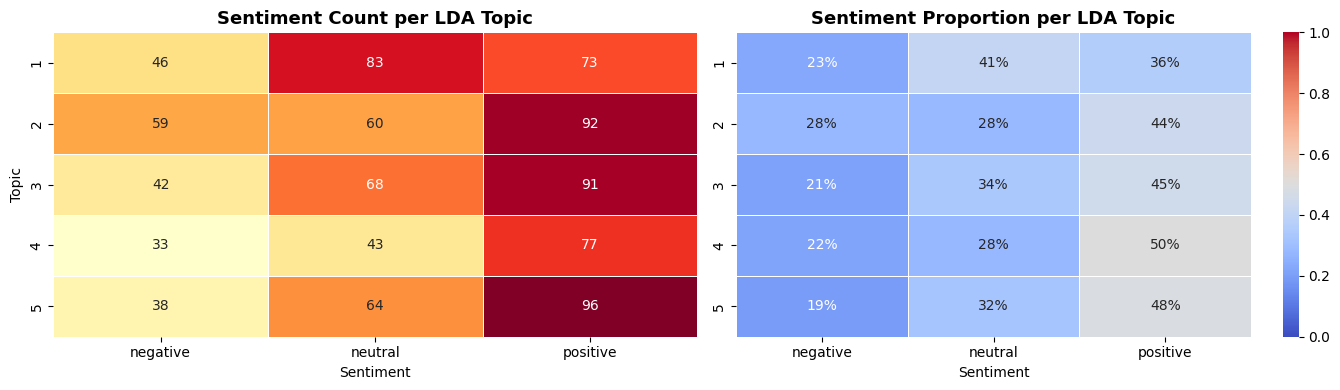

In [109]:
### 24. Sentiment Heatmap — VADER labels across LDA topics

# Cross-tab: rows = topics, cols = sentiment labels
ct = pd.crosstab(df['lda_topic'], df['vader_label'])
ct_pct = ct.div(ct.sum(axis=1), axis=0)   # normalise by row → % per topic

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: raw counts
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], cbar=False)
axes[0].set_title('Sentiment Count per LDA Topic', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Topic')

# Right: normalised (proportion)
sns.heatmap(ct_pct, annot=True, fmt='.0%', cmap='coolwarm',
            linewidths=0.5, ax=axes[1], cbar=True,
            vmin=0, vmax=1)
axes[1].set_title('Sentiment Proportion per LDA Topic', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('sentiment_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

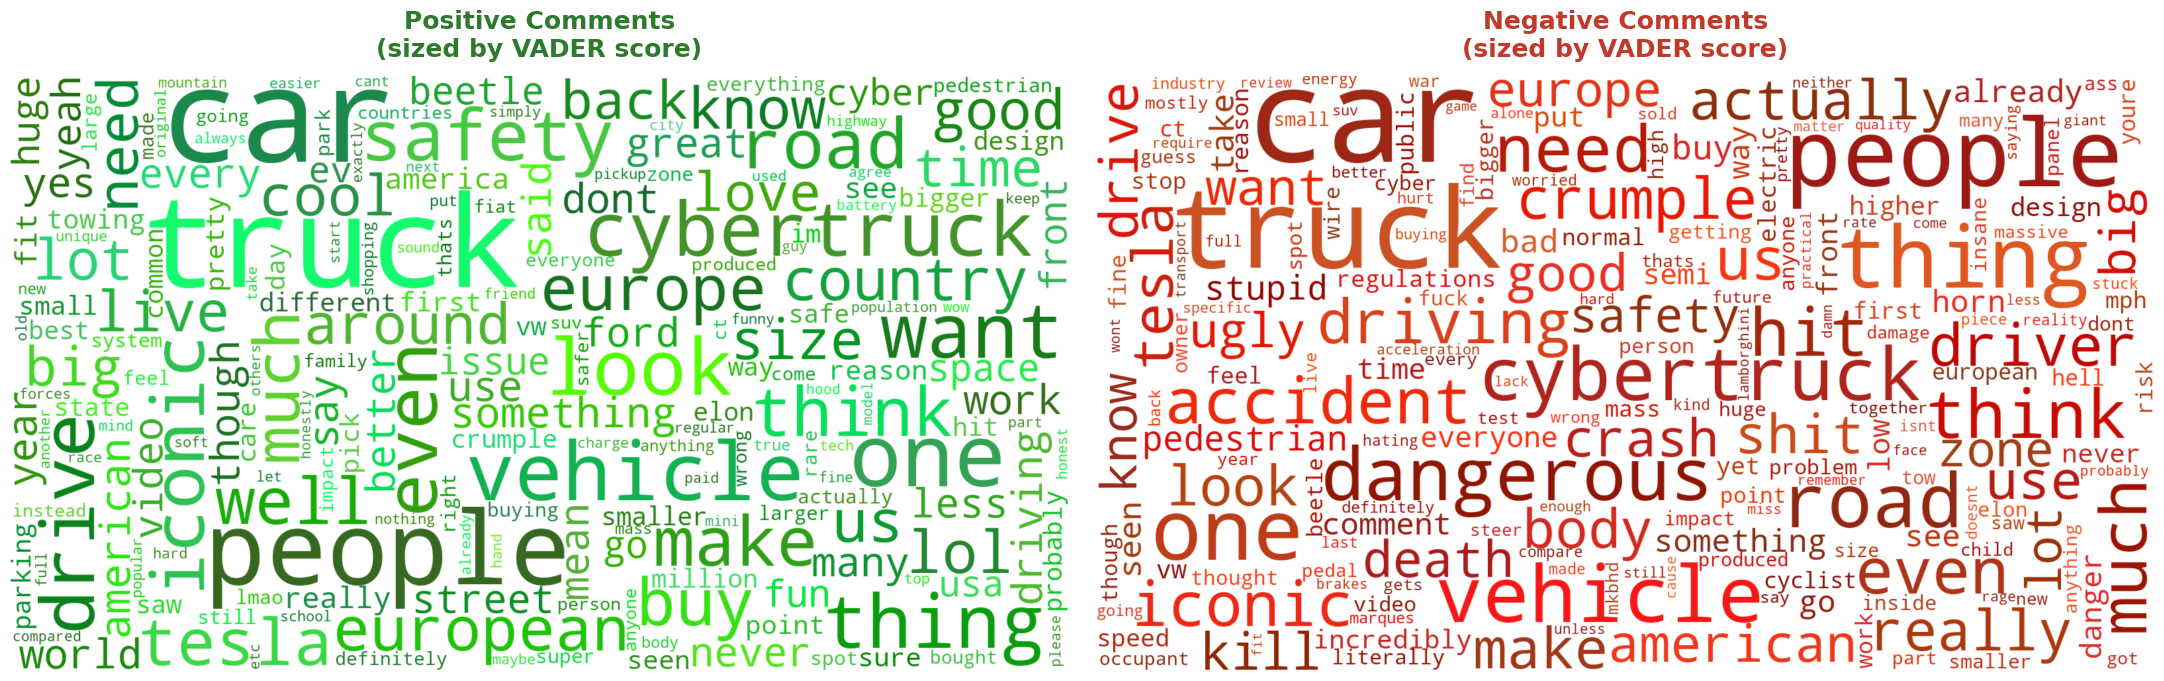

In [110]:
### 25. Word Clouds — weighted by VADER score (highest scorers dominate)

def green_func(word, font_size, position, orientation, random_state=None, **kw):
    return f'hsl({random_state.randint(100, 148)},{random_state.randint(50, 100)}%,{random_state.randint(25, 55)}%)'

def red_func(word, font_size, position, orientation, random_state=None, **kw):
    return f'hsl({random_state.randint(0, 18)},{random_state.randint(70, 100)}%,{random_state.randint(28, 55)}%)'

def weighted_corpus(subset_df, score_col):
    """Repeat each comment's tokens proportionally to its absolute VADER score.
    A comment with score 0.9 is repeated 9×; one with 0.1 only once."""
    parts = []
    for _, row in subset_df.iterrows():
        weight = max(1, round(abs(row[score_col]) * 10))
        text = str(row['text_filtered']) if pd.notna(row['text_filtered']) else ''
        parts.extend([text] * weight)
    return ' '.join(parts)

pos_df = df[df['vader_label'] == 'positive'].dropna(subset=['text_filtered'])
neg_df = df[df['vader_label'] == 'negative'].dropna(subset=['text_filtered'])

pos_corpus = weighted_corpus(pos_df, 'vader_score')
neg_corpus = weighted_corpus(neg_df, 'vader_score')

def make_wc(corpus, color_func):
    return WordCloud(
        width=1600, height=900,
        background_color='white',
        color_func=color_func,
        max_words=200,
        collocations=False,
        prefer_horizontal=0.80,
        relative_scaling=0.5,
        min_font_size=10,
        max_font_size=200,
        random_state=42,
    ).generate(corpus if corpus.strip() else 'no data')

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

axes[0].imshow(make_wc(pos_corpus, green_func), interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Comments\n(sized by VADER score)', fontsize=18, fontweight='bold', color='#2d7a2d', pad=14)

axes[1].imshow(make_wc(neg_corpus, red_func), interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Comments\n(sized by VADER score)', fontsize=18, fontweight='bold', color='#c0392b', pad=14)

plt.tight_layout(pad=2)
plt.savefig('wordclouds_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()